In [108]:
from pathlib import Path
import copy
import os
import random
import time
 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import MinMaxScaler
from torch import nn
from torch.utils.data import Dataset, DataLoader
 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(8, os.cpu_count() or 1))
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [109]:
data_path = Path("household_power_consumption.txt")
 
if not data_path.exists():
    raise FileNotFoundError(
        "Place household_power_consumption.txt in the same folder as this notebook."
    )
 
sensor_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]
 
dtypes = {col: "float32" for col in sensor_cols}
 
df = pd.read_csv(
    data_path,
    sep=";",
    na_values="?",
    usecols=["Date", "Time"] + sensor_cols,
    dtype=dtypes,
    low_memory=False
)
 
df["datetime"] = pd.to_datetime(
    df.pop("Date") + " " + df.pop("Time"),
    format="%d/%m/%Y %H:%M:%S"
)
 
df = df.set_index("datetime").sort_index()
 

In [110]:
missing_count = int(df.isna().sum().sum())
missing_pct = 100 * missing_count / df.size
 
mask = df["Global_active_power"].isna().to_numpy()
changes = np.diff(np.r_[False, mask, False].astype(int))
starts = np.where(changes == 1)[0]
ends = np.where(changes == -1)[0]
max_gap = int((ends - starts).max()) if len(starts) else 0

In [111]:
hourly = df.resample("h").mean()
coverage = df["Global_active_power"].resample("h").count()
 
low_coverage = coverage < 45
hourly.loc[low_coverage, sensor_cols] = np.nan
observed_target = (~low_coverage) & hourly["Global_active_power"].notna()
 
TEST_START = hourly.index.max() - pd.DateOffset(months=6)
VAL_START = TEST_START - pd.DateOffset(months=3)
train_rows = hourly.index < VAL_START
 
hourly[sensor_cols] = hourly[sensor_cols].ffill(limit=3)
 
hour_of_week = pd.Series(
    hourly.index.dayofweek * 24 + hourly.index.hour,
    index=hourly.index
)
 
for col in sensor_cols:
    medians = hourly.loc[train_rows, col].groupby(
        hour_of_week.loc[train_rows]
    ).median()
 
    missing = hourly[col].isna()
    hourly.loc[missing, col] = hour_of_week.loc[missing].map(medians)
    hourly[col] = hourly[col].fillna(
        hourly.loc[train_rows, col].median()
    )
 
print("Rows:", f"{len(df):,}")
print("Missing values:", f"{missing_count:,} ({missing_pct:.4f}%)")
print("Longest missing gap:", f"{max_gap:,} minutes")
print("Hourly rows:", f"{len(hourly):,}")
print(
    "Remaining missing values:",
    int(hourly[sensor_cols].isna().sum().sum())
)
print("Train:", hourly.index.min(), "to", VAL_START)
print("Validation:", VAL_START, "to", TEST_START)
print("Test:", TEST_START, "to", hourly.index.max())
 
hourly.to_csv("Assignment06_hourly_cleaned.csv")

Rows: 2,075,259
Missing values: 181,853 (1.2518%)
Longest missing gap: 7,226 minutes
Hourly rows: 34,589
Remaining missing values: 0
Train: 2006-12-16 17:00:00 to 2010-02-26 21:00:00
Validation: 2010-02-26 21:00:00 to 2010-05-26 21:00:00
Test: 2010-05-26 21:00:00 to 2010-11-26 21:00:00


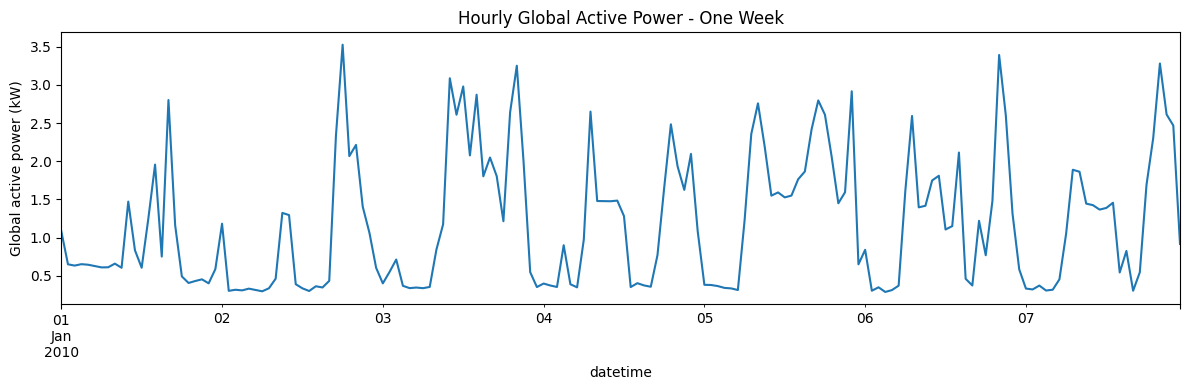

In [112]:
hourly.loc[
    "2010-01-01":"2010-01-07",
    "Global_active_power"
].plot(figsize=(12, 4))
 
plt.title("Hourly Global Active Power - One Week")
plt.ylabel("Global active power (kW)")
plt.tight_layout()
plt.show()

In [113]:
idx = hourly.index
 
hourly["hour_sin"] = np.sin(2 * np.pi * idx.hour / 24)
hourly["hour_cos"] = np.cos(2 * np.pi * idx.hour / 24)
hourly["dow_sin"] = np.sin(2 * np.pi * idx.dayofweek / 7)
hourly["dow_cos"] = np.cos(2 * np.pi * idx.dayofweek / 7)
hourly["year_sin"] = np.sin(2 * np.pi * idx.dayofyear / 365.25)
hourly["year_cos"] = np.cos(2 * np.pi * idx.dayofyear / 365.25)
 
feature_cols = sensor_cols + [
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "year_sin",
    "year_cos"
]
 
calendar_cols = [
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "year_sin",
    "year_cos"
]
 
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()
 
feature_scaler.fit(hourly.loc[train_rows, feature_cols])
 
# Fit target_scaler on the SAME representation it will transform (log1p),
# not on raw power - fitting on raw but transforming log1p silently squashes
# scaled targets into a narrow slice of [0, 1] and hurts learning.
target_scaler.fit(
    np.log1p(hourly.loc[train_rows, ["Global_active_power"]])
)
 
X_all = feature_scaler.transform(
    hourly[feature_cols]
).astype(np.float32)
 
y_all = target_scaler.transform(
    np.log1p(hourly[["Global_active_power"]])
).astype(np.float32).ravel()

calendar_all = hourly[calendar_cols].to_numpy(dtype=np.float32)

In [114]:
LOOKBACK = 168
HORIZON = 24
 
all_starts = np.arange(
    LOOKBACK,
    len(hourly) - HORIZON + 1
)
 
forecast_start = hourly.index[all_starts]
forecast_end = hourly.index[all_starts + HORIZON - 1]
 
observed = observed_target.to_numpy()
 
complete_target = np.array([
    observed[i:i + HORIZON].all()
    for i in all_starts
])
 
 
train_starts = all_starts[
    (forecast_end < VAL_START) & complete_target
]
 
val_starts = all_starts[
    (forecast_start >= VAL_START)
    & (forecast_end < TEST_START)
    & complete_target
][::24]
 
test_starts = all_starts[
    (forecast_start >= TEST_START) & complete_target
][::24]
 
print("Training windows:", len(train_starts))
print("Validation windows:", len(val_starts))
print("Test windows:", len(test_starts))

Training windows: 27398
Validation windows: 86
Test windows: 173


In [115]:
class WindowDataset(Dataset):
    
    def __init__(self, X, y, calendar, starts):
        self.X = X
        self.y = y
        self.calendar = calendar
        self.starts = np.asarray(starts, dtype=np.int64)
 
    def __len__(self):
        return len(self.starts)
 
    def __getitem__(self, index):
        i = int(self.starts[index])
 
        x_hist = self.X[i - LOOKBACK:i]
        future_cal = self.calendar[i:i + HORIZON]
        lag24 = self.y[i - 24:i - 24 + HORIZON]
        lag168 = self.y[i - 168:i - 168 + HORIZON]
        target = self.y[i:i + HORIZON]
 
        return (
            torch.from_numpy(x_hist),
            torch.from_numpy(future_cal),
            torch.from_numpy(lag24),
            torch.from_numpy(lag168),
            torch.from_numpy(target)
        )
 
 
train_loader = DataLoader(
    WindowDataset(X_all, y_all, calendar_all, train_starts),
    batch_size=128,
    shuffle=True
)
 
val_loader = DataLoader(
    WindowDataset(X_all, y_all, calendar_all, val_starts),
    batch_size=512,
    shuffle=False
)
 
test_loader = DataLoader(
    WindowDataset(X_all, y_all, calendar_all, test_starts),
    batch_size=512,
    shuffle=False
)
 

In [116]:
class LSTMForecast(nn.Module):
    
    def __init__(
        self,
        input_size,
        calendar_size=6,
        hidden_size=64,
        horizon=HORIZON
    ):
        super().__init__()
        self.horizon = horizon
 
        self.encoder = nn.LSTM(
            input_size,
            hidden_size,
            batch_first=True
        )
 
        decoder_input_size = hidden_size + calendar_size + 2  # + lag24 + lag168
 
        self.decoder_head = nn.Sequential(
            nn.Linear(decoder_input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(64, 1)
        )
 
    def forward(self, x_hist, future_cal, lag24, lag168):
        _, (hidden, _) = self.encoder(x_hist)
        context = hidden[-1]                                   # (batch, hidden)
        context = context.unsqueeze(1).expand(-1, self.horizon, -1)
 
        decoder_in = torch.cat([
            context,
            future_cal,
            lag24.unsqueeze(-1),
            lag168.unsqueeze(-1)
        ], dim=-1)
 
        residual = self.decoder_head(decoder_in).squeeze(-1)   # (batch, horizon)
        return lag24 + residual
 
 
model = LSTMForecast(len(feature_cols)).to(device)
 
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)
 
target_min = float(target_scaler.min_[0])
target_scale = float(target_scaler.scale_[0])


def to_kw(y_scaled):
    log_val = (y_scaled - target_min) / target_scale
    return torch.expm1(log_val)


def mape_loss(pred_scaled, y_scaled):
    pred_kw = to_kw(pred_scaled)
    actual_kw = to_kw(y_scaled)
    return torch.mean(
        torch.abs(actual_kw - pred_kw) / torch.clamp(actual_kw.abs(), min=0.05)
    )


loss_fn = mape_loss
 

In [117]:
def train_epoch(loader):
    model.train()
    total = 0.0
 
    for x_hist, future_cal, lag24, lag168, y_batch in loader:
        x_hist = x_hist.to(device)
        future_cal = future_cal.to(device)
        lag24 = lag24.to(device)
        lag168 = lag168.to(device)
        y_batch = y_batch.to(device)
 
        optimizer.zero_grad()
        pred = model(x_hist, future_cal, lag24, lag168)
        loss = loss_fn(pred, y_batch)
        loss.backward()
 
        nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )
 
        optimizer.step()
        total += loss.item() * x_hist.size(0)
 
    return total / len(loader.dataset)
 
 
@torch.no_grad()
def validation_loss(loader):
    model.eval()
    total = 0.0
 
    for x_hist, future_cal, lag24, lag168, y_batch in loader:
        x_hist = x_hist.to(device)
        future_cal = future_cal.to(device)
        lag24 = lag24.to(device)
        lag168 = lag168.to(device)
        y_batch = y_batch.to(device)
 
        pred = model(x_hist, future_cal, lag24, lag168)
        total += loss_fn(pred, y_batch).item() * x_hist.size(0)
 
    return total / len(loader.dataset)

In [118]:
best_state = None
best_loss = np.inf
wait = 0
patience = 7
 
for epoch in range(1, 41):
    start = time.perf_counter()
 
    train_loss = train_epoch(train_loader)
    val_loss = validation_loss(val_loader)
 
    print(
        f"Epoch {epoch:02d} | "
        f"train {train_loss:.4f} | "
        f"validation {val_loss:.4f} | "
        f"{time.perf_counter() - start:.1f}s"
    )
 
    if val_loss < best_loss - 1e-4:
        best_loss = val_loss
        best_state = copy.deepcopy(
            model.state_dict()
        )
        wait = 0
    else:
        wait += 1
 
        if wait >= patience:
            break
 
if best_state is not None:
    model.load_state_dict(best_state)
 

Epoch 01 | train 0.5889 | validation 0.4794 | 10.0s
Epoch 02 | train 0.4670 | validation 0.4454 | 9.7s
Epoch 03 | train 0.4481 | validation 0.4347 | 9.4s
Epoch 04 | train 0.4339 | validation 0.4417 | 9.6s
Epoch 05 | train 0.4249 | validation 0.4132 | 9.4s
Epoch 06 | train 0.4198 | validation 0.4241 | 9.5s
Epoch 07 | train 0.4166 | validation 0.4207 | 9.8s
Epoch 08 | train 0.4138 | validation 0.4189 | 9.5s
Epoch 09 | train 0.4116 | validation 0.4148 | 9.5s
Epoch 10 | train 0.4089 | validation 0.4226 | 9.5s
Epoch 11 | train 0.4079 | validation 0.4264 | 9.5s
Epoch 12 | train 0.4066 | validation 0.4244 | 9.4s


In [119]:
@torch.no_grad()
def predict(loader):
    model.eval()
    predictions = []
    actuals = []
 
    for x_hist, future_cal, lag24, lag168, y_batch in loader:
        pred = model(
            x_hist.to(device),
            future_cal.to(device),
            lag24.to(device),
            lag168.to(device)
        )
        predictions.append(pred.cpu().numpy())
        actuals.append(y_batch.numpy())
 
    return (
        np.vstack(predictions),
        np.vstack(actuals)
    )
 
 
pred_scaled, actual_scaled = predict(test_loader)
 
pred_log = target_scaler.inverse_transform(
    pred_scaled.reshape(-1, 1)
).reshape(pred_scaled.shape)
 
actual_log = target_scaler.inverse_transform(
    actual_scaled.reshape(-1, 1)
).reshape(actual_scaled.shape)
 
predicted = np.clip(
    np.expm1(pred_log),
    0,
    None
)
 
actual = np.expm1(actual_log)
 
mape = np.mean(
    np.abs(
        (actual - predicted)
        / np.maximum(np.abs(actual), 1e-3)
    )
) * 100
 
wape = (
    np.sum(np.abs(actual - predicted))
    / np.sum(np.abs(actual))
) * 100
 
mae = np.mean(
    np.abs(actual - predicted)
)
 
rmse = np.sqrt(
    np.mean((actual - predicted) ** 2)
)
 
results = pd.DataFrame({
    "Metric": ["MAPE", "WAPE", "MAE", "RMSE"],
    "Value": [mape, wape, mae, rmse]
})
 
print(results.to_string(index=False))
print("MAPE requirement met:", mape <= 10)

Metric     Value
  MAPE 40.612671
  WAPE 50.747097
   MAE  0.476314
  RMSE  0.729196
MAPE requirement met: False


In [120]:
naive_pred, naive_actual = [], []
 
for start in test_starts:
    actual_vals = hourly["Global_active_power"].iloc[start:start + HORIZON].to_numpy()
    naive_vals = hourly["Global_active_power"].iloc[start - 24:start - 24 + HORIZON].to_numpy()
    naive_pred.append(naive_vals)
    naive_actual.append(actual_vals)
 
naive_pred = np.array(naive_pred)
naive_actual = np.array(naive_actual)
 
naive_mape = np.mean(
    np.abs((naive_actual - naive_pred) / np.maximum(np.abs(naive_actual), 1e-3))
) * 100
 
naive_wape = (
    np.sum(np.abs(naive_actual - naive_pred))
    / np.sum(np.abs(naive_actual))
) * 100
 
print("Naive (yesterday, same hour) MAPE:", naive_mape)
print("Naive (yesterday, same hour) WAPE:", naive_wape)
 

Naive (yesterday, same hour) MAPE: 64.63103294372559
Naive (yesterday, same hour) WAPE: 52.593302726745605


In [121]:
naive_pred, naive_actual = [], []

for start in test_starts:
    actual_vals = hourly["Global_active_power"].iloc[start:start+HORIZON].to_numpy()
    naive_vals = hourly["Global_active_power"].iloc[start-24:start-24+HORIZON].to_numpy()
    naive_pred.append(naive_vals)
    naive_actual.append(actual_vals)

naive_pred = np.array(naive_pred)
naive_actual = np.array(naive_actual)

naive_mape = np.mean(np.abs((naive_actual - naive_pred) / np.maximum(np.abs(naive_actual), 1e-3))) * 100
naive_wape = np.sum(np.abs(naive_actual - naive_pred)) / np.sum(np.abs(naive_actual)) * 100

print("Naive (yesterday, same hour) MAPE:", naive_mape)
print("Naive (yesterday, same hour) WAPE:", naive_wape)

Naive (yesterday, same hour) MAPE: 64.63103294372559
Naive (yesterday, same hour) WAPE: 52.593302726745605


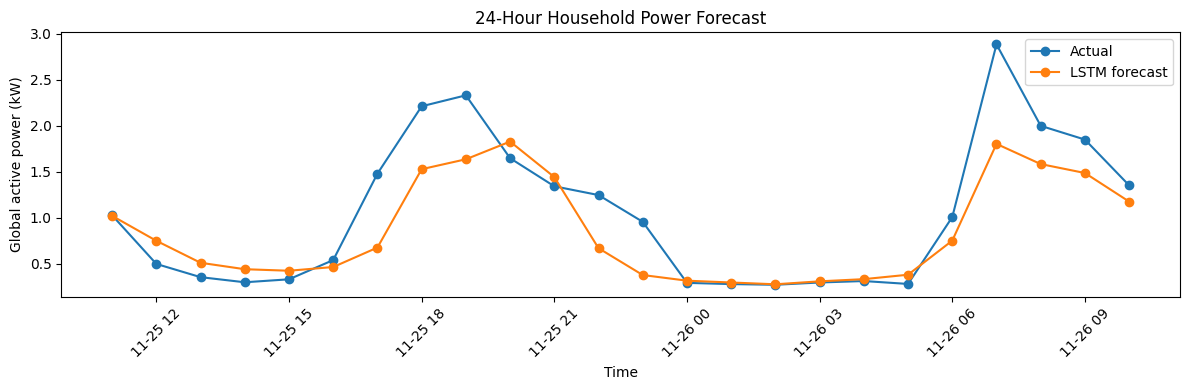

In [122]:
sample = -1
sample_start = hourly.index[test_starts[sample]]
 
hours = pd.date_range(
    sample_start,
    periods=HORIZON,
    freq="h"
)
 
plt.figure(figsize=(12, 4))
plt.plot(
    hours,
    actual[sample],
    marker="o",
    label="Actual"
)
plt.plot(
    hours,
    predicted[sample],
    marker="o",
    label="LSTM forecast"
)
 
plt.title("24-Hour Household Power Forecast")
plt.xlabel("Time")
plt.ylabel("Global active power (kW)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [123]:
# Requirement 4: Inference latency

single_index = int(test_starts[0])
 
x_hist_single = torch.from_numpy(
    X_all[single_index - LOOKBACK:single_index]
).unsqueeze(0).to(device)
 
future_cal_single = torch.from_numpy(
    calendar_all[single_index:single_index + HORIZON]
).unsqueeze(0).to(device)
 
lag24_single = torch.from_numpy(
    y_all[single_index - 24:single_index - 24 + HORIZON]
).unsqueeze(0).to(device)
 
lag168_single = torch.from_numpy(
    y_all[single_index - 168:single_index - 168 + HORIZON]
).unsqueeze(0).to(device)
 
model.eval()
 
with torch.no_grad():
    for _ in range(5):
        _ = model(x_hist_single, future_cal_single, lag24_single, lag168_single)
 
n_runs = 100
timings = []
 
with torch.no_grad():
    for _ in range(n_runs):
        run_start = time.perf_counter()
        _ = model(x_hist_single, future_cal_single, lag24_single, lag168_single)
        timings.append((time.perf_counter() - run_start) * 1000)  # ms
 
timings = np.array(timings)
 
print(f"Mean inference latency: {timings.mean():.2f} ms")
print(f"95th percentile latency: {np.percentile(timings, 95):.2f} ms")
print(f"Max latency: {timings.max():.2f} ms")
print("Latency requirement met (<500ms):", timings.mean() < 500)
 

Mean inference latency: 1.44 ms
95th percentile latency: 1.55 ms
Max latency: 1.83 ms
Latency requirement met (<500ms): True


In [124]:
pred_val_scaled, actual_val_scaled = predict(val_loader)

pred_val_log = target_scaler.inverse_transform(
    pred_val_scaled.reshape(-1, 1)
).reshape(pred_val_scaled.shape)

actual_val_log = target_scaler.inverse_transform(
    actual_val_scaled.reshape(-1, 1)
).reshape(actual_val_scaled.shape)

predicted_val = np.clip(np.expm1(pred_val_log), 0, None)
actual_val = np.expm1(actual_val_log)

val_residuals = actual_val - predicted_val
residual_std = val_residuals.std()


def has_consecutive_run(flags, min_run=2):
    run = 0
    for flag in flags:
        run = run + 1 if flag else 0
        if run >= min_run:
            return True
    return False


def alert_rate_for_multiplier(residuals, k, std):
    thresh = k * std
    anomalous = np.abs(residuals) > thresh
    alerts = np.array([has_consecutive_run(row, min_run=2) for row in anomalous])
    return alerts.mean() * 100

candidate_k = np.arange(3.0, 10.05, 0.1)
val_rates = [
    alert_rate_for_multiplier(val_residuals, k, residual_std)
    for k in candidate_k
]

TARGET_RATE = 1.0 
chosen_k = candidate_k[next(
    i for i, rate in enumerate(val_rates) if rate <= TARGET_RATE
)]

threshold = chosen_k * residual_std

print(f"Validation residual std: {residual_std:.4f} kW")
print(f"Calibrated sigma multiplier: {chosen_k:.1f}")
print(f"Anomaly threshold: {threshold:.4f} kW")

test_residuals = actual - predicted
anomalous_hours = np.abs(test_residuals) > threshold

household_alerts = np.array([
    has_consecutive_run(row, min_run=2) for row in anomalous_hours
])

alert_rate = household_alerts.mean() * 100

print(
    "Household windows flagged for alert:",
    f"{household_alerts.sum()} / {len(household_alerts)}"
)
print(f"Alert (false-alarm proxy) rate: {alert_rate:.2f}%")
print("False-alarm rate requirement met (<5%):", alert_rate < 5)

Validation residual std: 0.6394 kW
Calibrated sigma multiplier: 5.2
Anomaly threshold: 3.3250 kW
Household windows flagged for alert: 0 / 173
Alert (false-alarm proxy) rate: 0.00%
False-alarm rate requirement met (<5%): True
